# Results Overview
## Predicting the Failure of Crowded Technical Signals — EURO STOXX 50

This notebook visualises the full pipeline output:
- Alert distribution
- Label base rates by alert type
- ML metrics across horizons
- Feature importance
- Strategy comparison

In [ ]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110

In [ ]:
# ── Load artefacts ──────────────────────────────────────────────────────────
labeled    = pd.read_parquet('../data/features/events_labeled.parquet')
ml_metrics = pd.read_csv('../results/reports/ml_metrics.csv')
strat      = pd.read_csv('../results/reports/strategy_comparison.csv')

fi = {}
for h in [1, 3, 5]:
    try:
        fi[h] = pd.read_csv(f'../results/reports/feature_importance_h{h}d.csv',
                             index_col=0, header=0, names=['feature', 'importance'])
    except FileNotFoundError:
        pass

labeled['date'] = pd.to_datetime(labeled['date'])
print(f'Events: {len(labeled):,}  |  Tickers: {labeled["ticker"].nunique()}  |  Alerts: {labeled["alert_name"].nunique()}')
labeled.head(3)

Events: 178,326  |  Tickers: 49  |  Alerts: 18


,date,ticker,alert_name,direction,n_simultaneous_alerts,fwd_ret_1d,fwd_ret_3d,fwd_ret_5d,label_failure_1d,label_failure_3d,label_failure_5d
0,2010-02-02,ABI.BR,breakout_high_20,bullish,1,-0.005997,-0.071283,-0.047431,1.0,1.0,1.0
1,2010-02-17,ABI.BR,breakout_high_20,bullish,1,0.001878,-0.018513,-0.006708,0.0,1.0,1.0
2,2010-02-18,ABI.BR,breakout_high_20,bullish,1,-0.001607,-0.024103,-0.029191,0.0,1.0,1.0


## 1. Alert Distribution

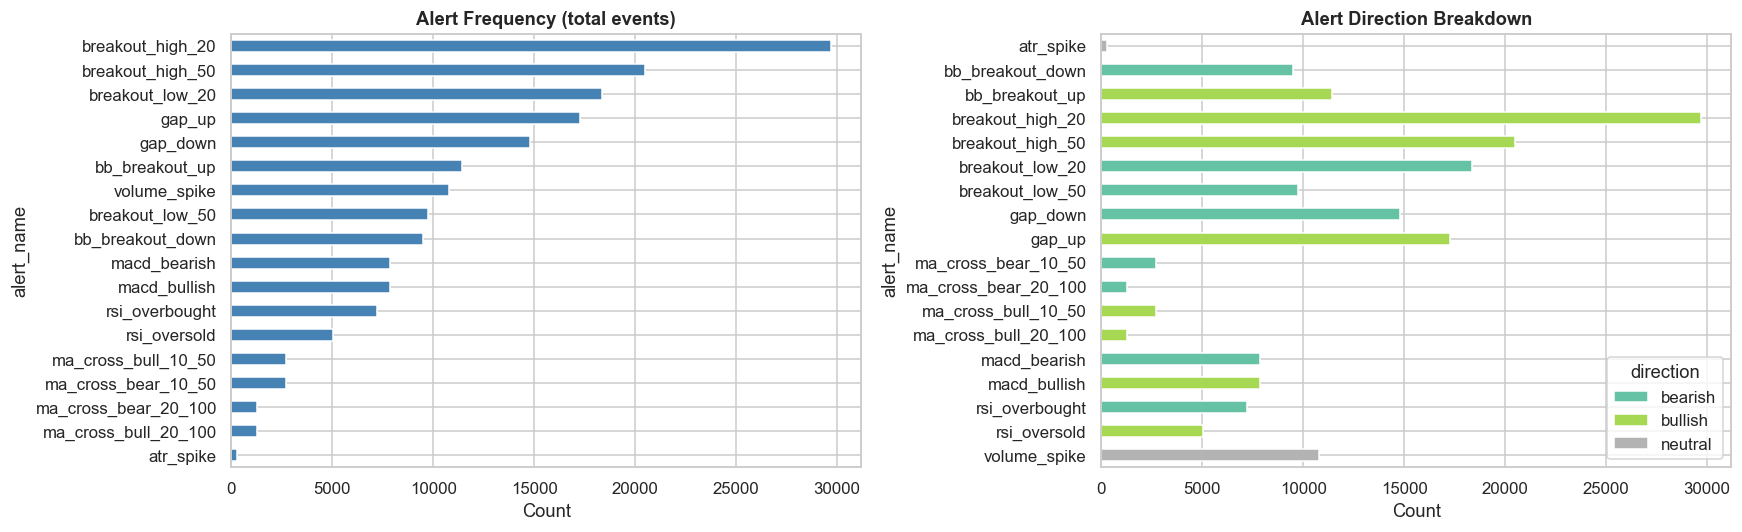

In [ ]:
alert_counts = labeled['alert_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume by alert
alert_counts.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Alert Frequency (total events)', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Direction breakdown
dir_counts = labeled.groupby(['alert_name', 'direction']).size().unstack(fill_value=0)
dir_counts.plot.barh(ax=axes[1], stacked=True, colormap='Set2')
axes[1].set_title('Alert Direction Breakdown', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../results/reports/alert_distribution.png', bbox_inches='tight')
plt.show()

## 2. Failure Rates by Alert Type

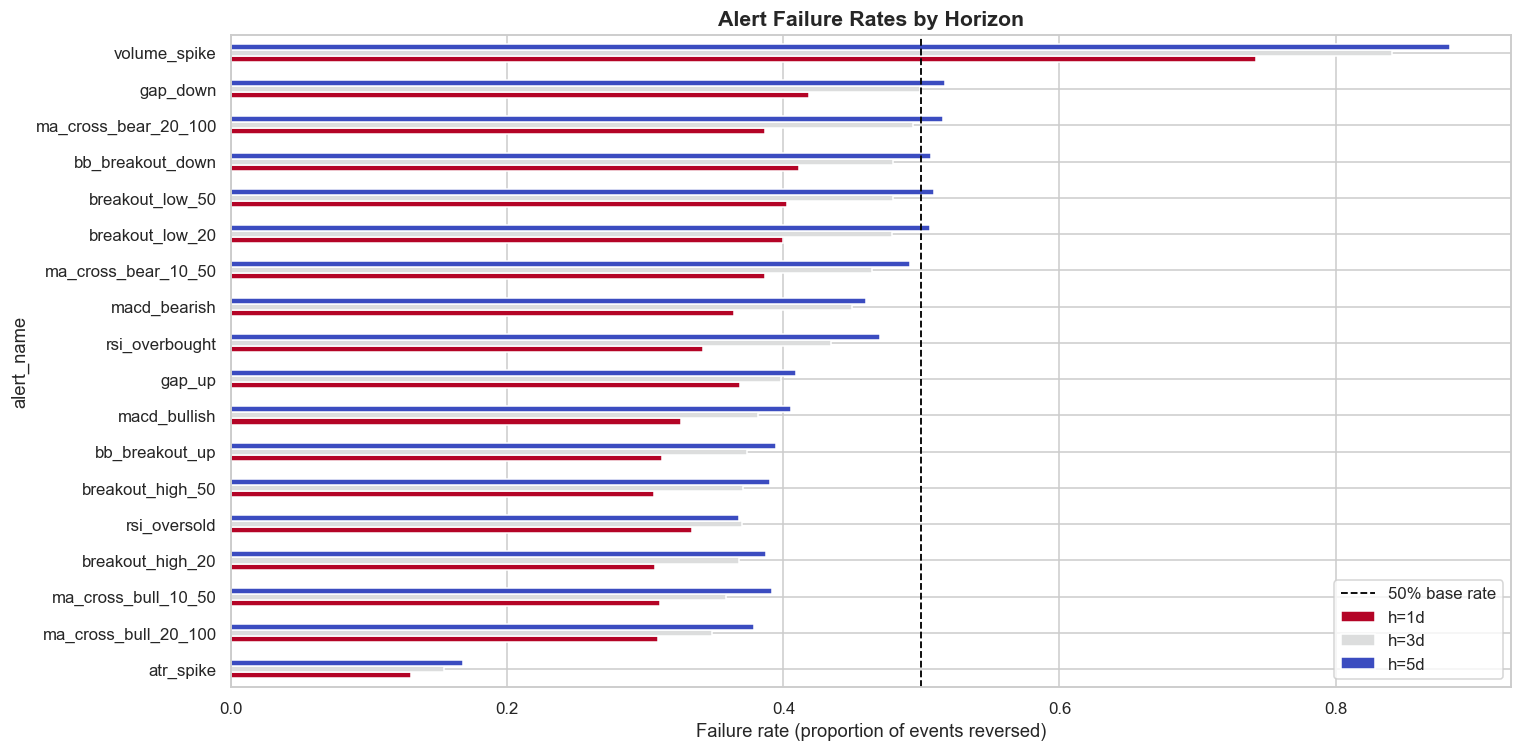

                          h=1d      h=3d      h=5d
alert_name                                        
volume_spike          0.742264  0.840838  0.883268
gap_down              0.418641  0.499255  0.517395
ma_cross_bear_20_100  0.386895  0.493760  0.515601
bb_breakout_down      0.411567  0.479390  0.506625
breakout_low_50       0.402811  0.479229  0.509283
breakout_low_20       0.399935  0.478561  0.505877
ma_cross_bear_10_50   0.386533  0.464286  0.491443
macd_bearish          0.363925  0.449733  0.459634
rsi_overbought        0.342039  0.434426  0.470270
gap_up                0.368318  0.398577  0.408933
macd_bullish          0.325741  0.381346  0.405650
bb_breakout_up        0.312221  0.373982  0.394569
breakout_high_50      0.306510  0.370632  0.390055
rsi_oversold          0.333864  0.369877  0.367887
breakout_high_20      0.306799  0.367830  0.387209
ma_cross_bull_10_50   0.310766  0.358121  0.391417
ma_cross_bull_20_100  0.309133  0.348165  0.378610
atr_spike             0.130137 

In [ ]:
failure_by_alert = (
    labeled.groupby('alert_name')[['label_failure_1d', 'label_failure_3d', 'label_failure_5d']]
    .mean()
    .sort_values('label_failure_3d', ascending=True)
)
failure_by_alert.columns = ['h=1d', 'h=3d', 'h=5d']

ax = failure_by_alert.plot.barh(figsize=(14, 7), colormap='coolwarm_r')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% base rate')
ax.set_title('Alert Failure Rates by Horizon', fontweight='bold', fontsize=14)
ax.set_xlabel('Failure rate (proportion of events reversed)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/reports/failure_rates_by_alert.png', bbox_inches='tight')
plt.show()

print(failure_by_alert.sort_values('h=3d', ascending=False).to_string())

## 3. ML Metrics Summary

 horizon  roc_auc  pr_auc  top_decile_precision     f1  base_rate  n_samples
       1   0.6051  0.4918                0.6398 0.4600     0.3717     142969
       3   0.5974  0.5543                0.7278 0.4821     0.4394     142969
       5   0.5862  0.5633                0.7364 0.4848     0.4596     142969


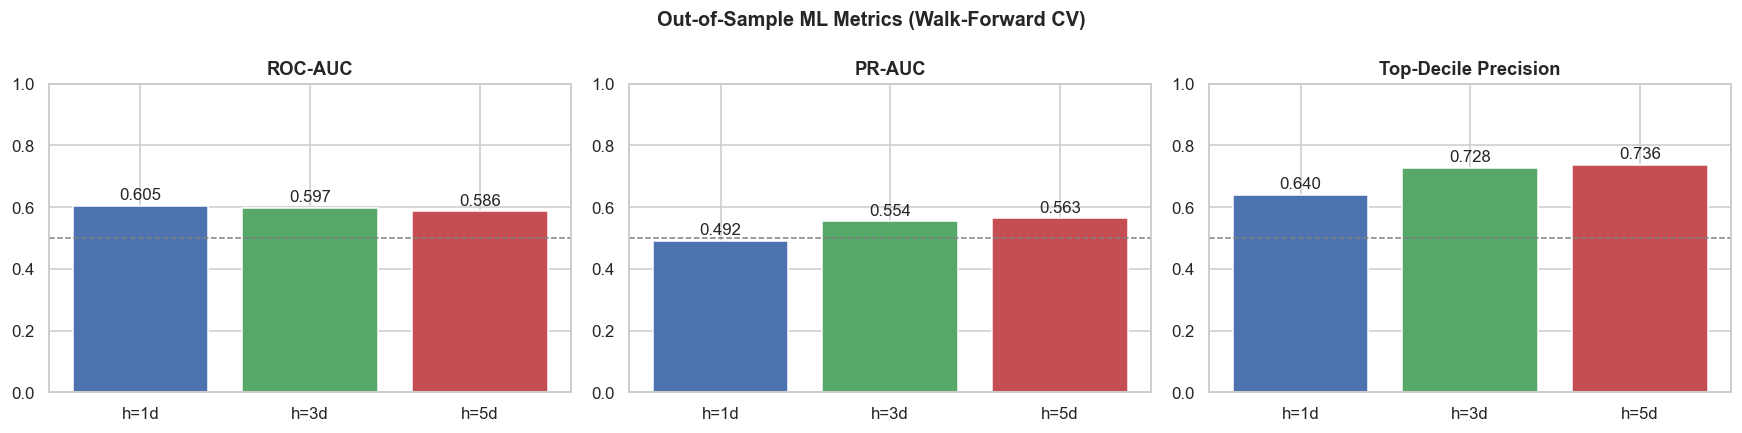

In [ ]:
display_cols = ['horizon', 'roc_auc', 'pr_auc', 'top_decile_precision', 'f1', 'base_rate', 'n_samples']
print(ml_metrics[display_cols].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics_to_plot = ['roc_auc', 'pr_auc', 'top_decile_precision']
titles = ['ROC-AUC', 'PR-AUC', 'Top-Decile Precision']

for ax, col, title in zip(axes, metrics_to_plot, titles):
    bars = ax.bar([f'h={h}d' for h in ml_metrics['horizon']], ml_metrics[col],
                  color=['#4C72B0', '#55A868', '#C44E52'])
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, ml_metrics[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Out-of-Sample ML Metrics (Walk-Forward CV)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/reports/ml_metrics_chart.png', bbox_inches='tight')
plt.show()

## 4. Feature Importance (h=3d)

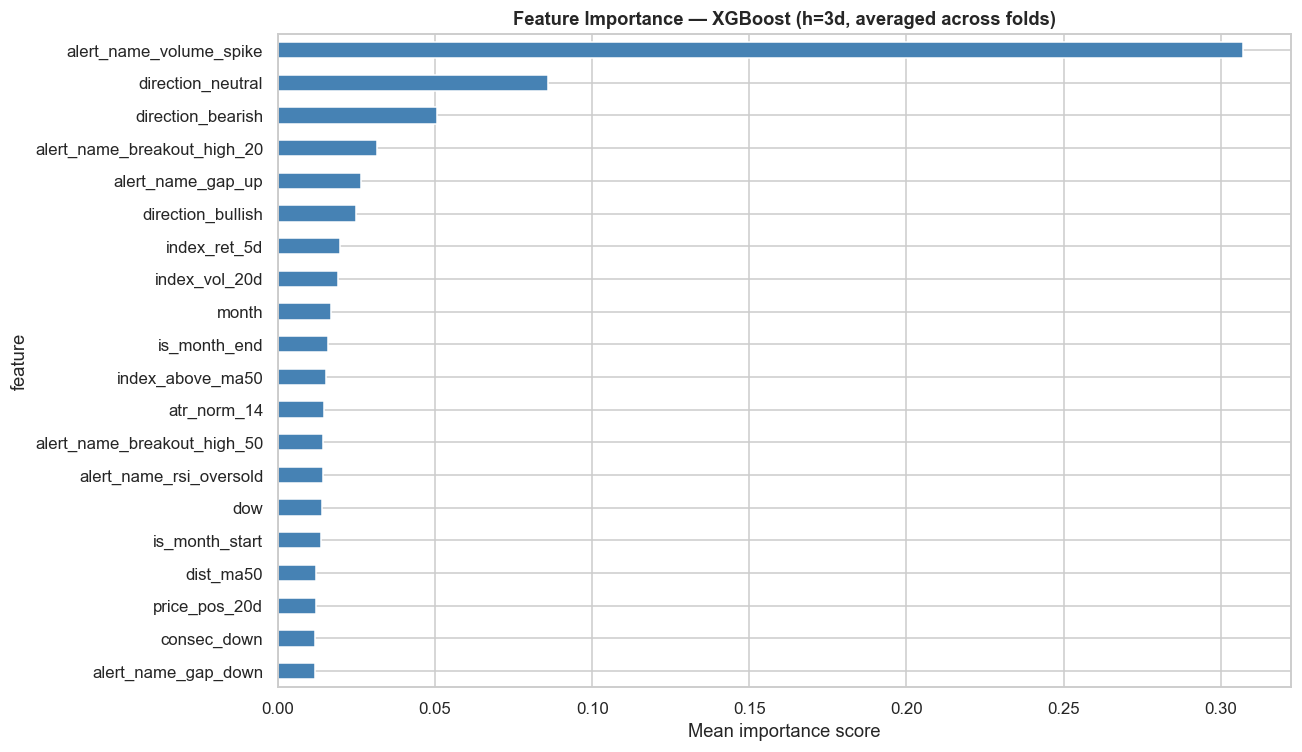

In [ ]:
if 3 in fi:
    top20 = fi[3].head(20)
    ax = top20.plot.barh(legend=False, color='steelblue', figsize=(12, 7))
    ax.invert_yaxis()
    ax.set_title('Feature Importance — XGBoost (h=3d, averaged across folds)', fontweight='bold')
    ax.set_xlabel('Mean importance score')
    plt.tight_layout()
    plt.savefig('../results/reports/feature_importance_chart.png', bbox_inches='tight')
    plt.show()
else:
    print('Feature importance file not found. Run pipeline first.')

## 5. Strategy Comparison

 horizon  follow_alert_sharpe  follow_alert_hit_rate  follow_alert_net_ret  follow_alert_n_trades  blind_inverse_sharpe  blind_inverse_hit_rate  blind_inverse_net_ret  blind_inverse_n_trades  ml_filtered_sharpe  ml_filtered_hit_rate  ml_filtered_net_ret  ml_filtered_n_trades
       1               -0.843                  0.490              -0.00106                 133834                -0.747                   0.495               -0.00094                  133834               0.938                 0.561              0.00195                 10968
       3               -0.458                  0.497              -0.00100                 133704                -0.459                   0.496               -0.00100                  133704               0.620                 0.574              0.00221                 12057
       5               -0.395                  0.498              -0.00113                 133618                -0.304                   0.497               -0.00087      

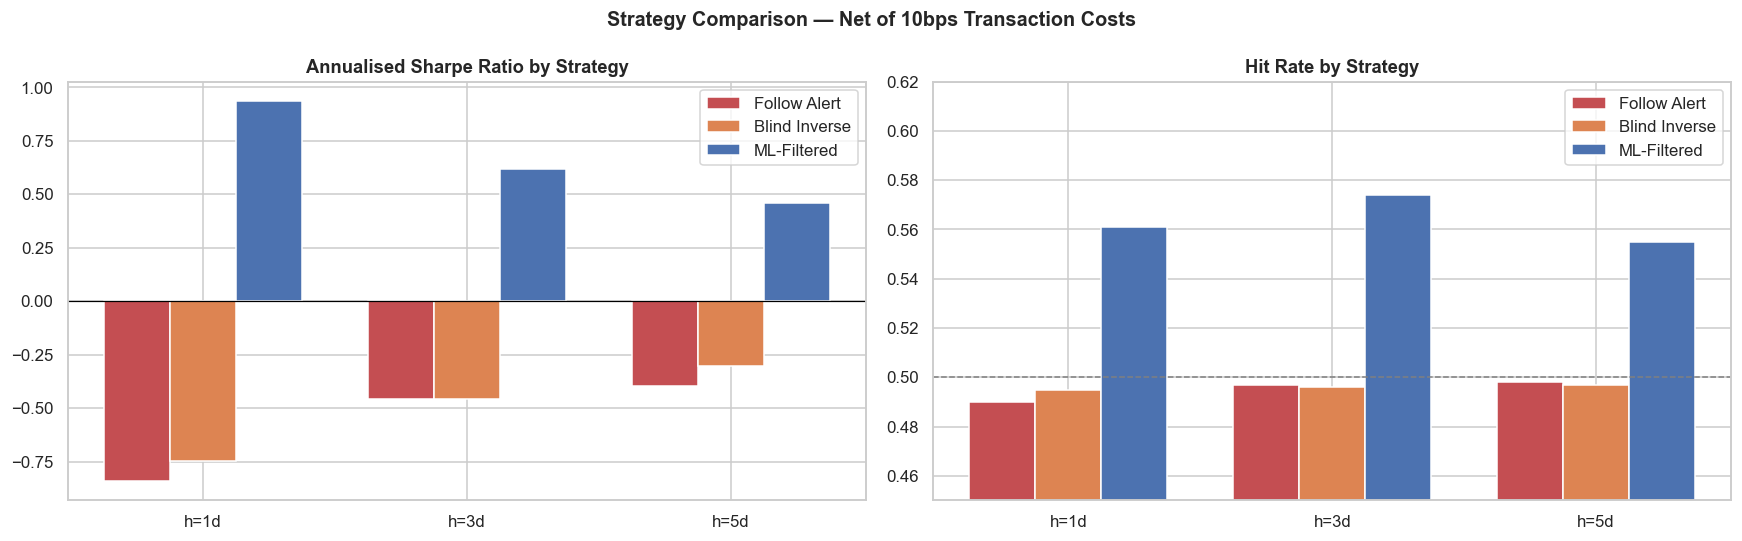

In [ ]:
print(strat.to_string(index=False))

horizons = strat['horizon'].tolist()
x = np.arange(len(horizons))
width = 0.25
colors = ['#C44E52', '#DD8452', '#4C72B0']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sharpe ratio
for i, (col, label) in enumerate([
    ('follow_alert_sharpe', 'Follow Alert'),
    ('blind_inverse_sharpe', 'Blind Inverse'),
    ('ml_filtered_sharpe', 'ML-Filtered'),
]):
    axes[0].bar(x + i*width, strat[col], width, label=label, color=colors[i])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([f'h={h}d' for h in horizons])
axes[0].set_title('Annualised Sharpe Ratio by Strategy', fontweight='bold')
axes[0].legend()

# Hit rate
for i, (col, label) in enumerate([
    ('follow_alert_hit_rate', 'Follow Alert'),
    ('blind_inverse_hit_rate', 'Blind Inverse'),
    ('ml_filtered_hit_rate', 'ML-Filtered'),
]):
    axes[1].bar(x + i*width, strat[col], width, label=label, color=colors[i])
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([f'h={h}d' for h in horizons])
axes[1].set_title('Hit Rate by Strategy', fontweight='bold')
axes[1].set_ylim(0.45, 0.62)
axes[1].legend()

plt.suptitle('Strategy Comparison — Net of 10bps Transaction Costs', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/reports/strategy_comparison_chart.png', bbox_inches='tight')
plt.show()

## 6. Alerts Over Time

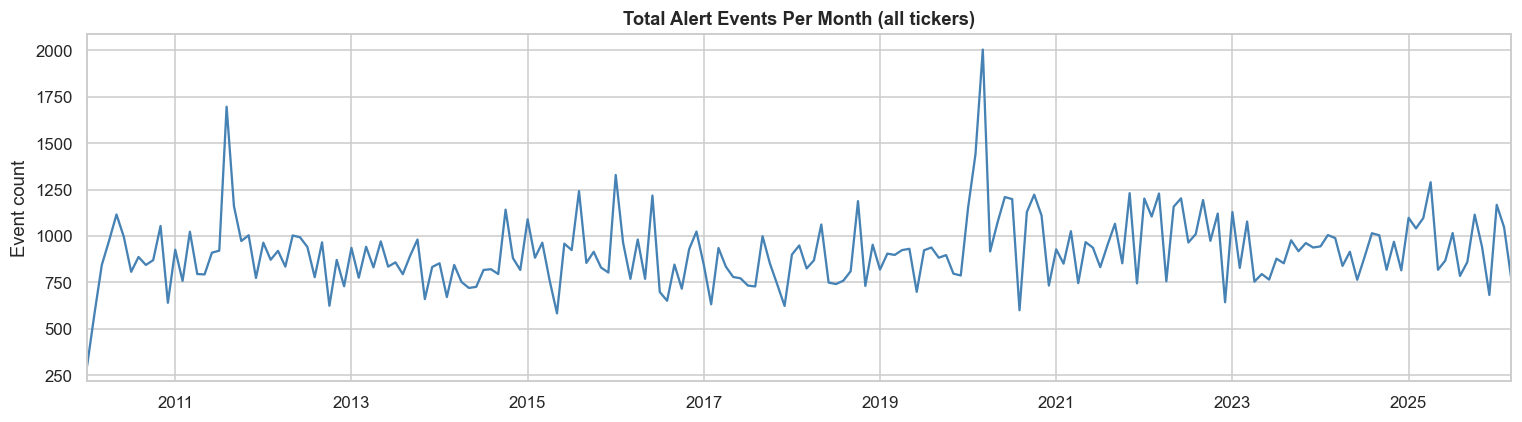

In [ ]:
monthly = (
    labeled.set_index('date')
    .resample('ME')['alert_name']
    .count()
)
ax = monthly.plot(figsize=(14, 4), color='steelblue')
ax.set_title('Total Alert Events Per Month (all tickers)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Event count')
plt.tight_layout()
plt.savefig('../results/reports/alerts_over_time.png', bbox_inches='tight')
plt.show()

## 7. Key Takeaways

In [ ]:
print('=== KEY FINDINGS ===')
print()
print('1. SIGNAL RELIABILITY')
print(f'   Average failure rate h=1d: {labeled["label_failure_1d"].mean():.1%}')
print(f'   Average failure rate h=3d: {labeled["label_failure_3d"].mean():.1%}')
print(f'   Average failure rate h=5d: {labeled["label_failure_5d"].mean():.1%}')
print()
print('2. MODEL EDGE')
for _, row in ml_metrics.iterrows():
    print(f'   h={int(row.horizon)}d  ROC-AUC={row.roc_auc:.3f}  '
          f'Top-decile-precision={row.top_decile_precision:.3f}')
print()
print('3. STRATEGY EDGE')
for _, row in strat.iterrows():
    print(f'   h={int(row.horizon)}d  ML-Filtered Sharpe={row.ml_filtered_sharpe:.2f}  '
          f'Hit rate={row.ml_filtered_hit_rate:.1%}  '
          f'Trades={int(row.ml_filtered_n_trades):,}')
print()
print('4. MOST PREDICTIVE FEATURES (h=3d)')
if 3 in fi:
    for feat, imp in fi[3].head(5).iterrows():
        print(f'   {feat}: {imp.values[0]:.4f}')

=== KEY FINDINGS ===

1. SIGNAL RELIABILITY
   Average failure rate h=1d: 37.6%
   Average failure rate h=3d: 44.3%
   Average failure rate h=5d: 46.5%

2. MODEL EDGE
   h=1d  ROC-AUC=0.605  Top-decile-precision=0.640
   h=3d  ROC-AUC=0.597  Top-decile-precision=0.728
   h=5d  ROC-AUC=0.586  Top-decile-precision=0.736

3. STRATEGY EDGE
   h=1d  ML-Filtered Sharpe=0.94  Hit rate=56.1%  Trades=10,968
   h=3d  ML-Filtered Sharpe=0.62  Hit rate=57.4%  Trades=12,057
   h=5d  ML-Filtered Sharpe=0.46  Hit rate=55.5%  Trades=14,049

4. MOST PREDICTIVE FEATURES (h=3d)
   alert_name_volume_spike: 0.3071
   direction_neutral: 0.0859
   direction_bearish: 0.0507
   alert_name_breakout_high_20: 0.0316
   alert_name_gap_up: 0.0265
